Testing - Cane segmentation


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

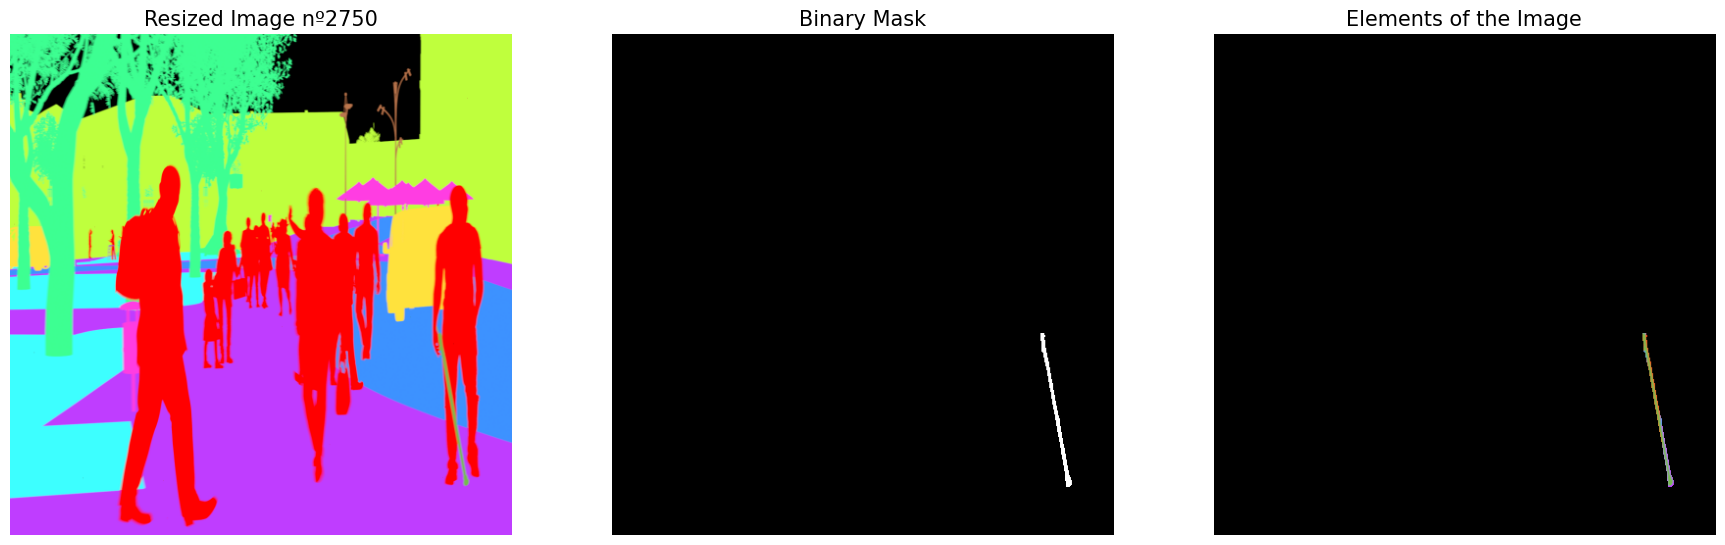

In [ ]:
"""
Images (Status) from 2735 to 2792.
2735 (OK), 2736 (OK), 2737 (OK), 2738 (OK), 2739 (OK), 2740 (OK), 2741 (OK), 2742(OK), 2743 (OK), 2744 (OK), 2745 (OK),
2746 (OK), 2747 (OK), 2748 (OK), 2749 (OK), 2750 (OK), 2751 (OK), 2752 (OK), 2753 (OK), 2754 (OK), 2755 (OK),
2756 (OK), 2757 (OK), 2758 (OK), 2759 (OK), 2760 (OK), 2761 (OK), 2762 (OK), 2763 (OK), 2764 (OK), 2765 (OK),
2766 (OK), 2767 (OK), 2768 (OK), 2769 (OK), 2770 (OK), 2771 (OK), 2772 (OK), 2773 (OK), 2774 (OK), 2775 (OK),
2776 (OK), 2777 (OK), 2778 (OK), 2779 (OK), 2780 (OK), 2781 (OK), 2782 (OK), 2783 (OK), 2784 (OK), 2785 (OK),
2786 (OK), 2787 (OK), 2788 (OK), 2789 (OK), 2790 (OK), 2791 (OK), 2792 (FAIL)


Images (Status) from 2635.
2635 (OK)
"""

import sys
import os

# Add the project root folder path to sys.path
# project_path = '/home/santiago/Doctorado/Entrenamientos/renato/pucpr_pibic_semantic_segmentation'
project_path = '/media/renato/Data/Work/pucpr_pibit_semantic_segmentation/'
sys.path.append(os.path.abspath(project_path))

from dotenv import load_dotenv
from core.validation import get_valid_image_number
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
# base_mask_folder: str = r"C:\Users\SLR02\Pictures\prueba 3\FinalImagePPM_Mask"
# output_folder: str = os.getenv("OUTPUT_FOLDER")
# mask_path: str = os.path.join(base_mask_folder, f"{441}.png")

base_mask_folder: str = os.getenv("BASE_MASK_FOLDER")
img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

# Load and Convert Images
bgr_img = cv.imread(mask_path, 1)
hsv_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)

### Process 1 - Extraction of the desired color ###
# Define limits for the color you want to extract in HSV
# original color
# lower_bound = np.array([49, 145, 186]) # Hue, Saturation, Value
# upper_bound = np.array([50, 151, 187]) # Hue, Saturation, Value

# 1st attempt
# lower_bound = np.array([43, 145, 183]) # Hue, Saturation, Value
# upper_bound = np.array([50, 151, 187]) # Hue, Saturation, Value

# 2nd attempt
# lower_bound = np.array([35, 145, 172]) # Hue, Saturation, Value
# upper_bound = np.array([50, 151, 187]) # Hue, Saturation, Value

# 3rd attempt (need refining)
lower_bound = np.array([31, 145, 165]) # Hue, Saturation, Value
upper_bound = np.array([50, 151, 187]) # Hue, Saturation, Value
mask_extraction = cv.inRange(hsv_img, lower_bound, upper_bound)


### Process 3 - Region Growth
import collections


### Define target color ###
# Average extraction range: ((35 + 50) // 2, (145 + 151) // 2, (172 + 187) // 2) = [40, 148, 178]
target_color = np.array([(31 + 50) // 2, (145 + 151) // 2, (165 + 187) // 2])

### Region growing from extraction ###
# A region growing mask is created. Initially, it contains the extraction.
region_mask = np.zeros_like(mask_extraction, dtype=np.uint8)
region_mask[mask_extraction == 255] = 255

# We use a queue to implement region growth
queue = collections.deque()

# We add the initial pixels of the extraction
indexes = np.column_stack(np.where(mask_extraction == 255))
for index in indexes:
    queue.append(tuple(index))

# Helper function: boundary condition based on the obtained ranges in HSV
def fulfill_condition(H, S, V):
    # cane_condition = ((32 <= H <= 72) and (50 <= S <= 163) and (163 <= V <= 214))
    # cane_condition = ((20 <= H <= 77) and (30 <= S <= 170) and (160 <= V <= 214))
    # cane_condition = ((20 <= H <= 100) and (10 <= S <= 170) and (160 <= V <= 214))
    # cane_condition = ((0 <= H <= 130) and (5 <= S <= 190) and (158 <= V <= 200))
    # cane_condition = ((0 <= H <= 145) and (5 <= S <= 190) and (158 <= V <= 200))
    cane_condition = ((0 <= H <= 139) and (5 <= S <= 180) and (158 <= V <= 195))
    return cane_condition

# We perform the growth: for each pixel in the region, its neighbors are analyzed.
while queue:
    i, j = queue.popleft()
    # For 8 Neighbors (it's possible expand the neighborhood if necessary)
    for di, dj in [
                    (-1, -1), (-1, 0), (-1, 1),
                    (0, -1),           (0, 1),
                    (1, -1),  (1, 0),  (1, 1)
                ]:
        ni, nj = i + di, j + dj
        # Check that the neighbor is within the image
        if 0 <= ni < hsv_img.shape[0] and 0 <= nj < hsv_img.shape[1]:
            # If the neighbor is not yet part of the growth region:
            if region_mask[ni, nj] == 0:
                H, S, V = hsv_img[ni, nj]
                if fulfill_condition(H, S, V):
                    region_mask[ni, nj] = 255
                    queue.append((ni, nj))


# Morphologic Operation
# 3. Post-processing
kernel = np.ones((2,2), np.uint8)   # add noise to other images, but we maintain the 2 canes. Apply contour filter after!
# kernel = np.ones((3,3), np.uint8)
# kernel = np.ones((4,4), np.uint8)
# kernel = np.ones((5,5), np.uint8)   # Good, but lose details for the second cane
# kernel = np.ones((6,6), np.uint8)
# kernel = np.ones((7,7), np.uint8)
# kernel = np.ones((8,8), np.uint8)
# kernel = np.ones((9,9), np.uint8)
# kernel = np.ones((10,10), np.uint8)
# mask = cv.morphologyEx(region_mask, cv.MORPH_CLOSE, kernel) # Close small holes
mask = cv.morphologyEx(region_mask, cv.MORPH_CLOSE, kernel) # Close small holes
mask = cv.morphologyEx(mask, cv.MORPH_OPEN, kernel) # Remove small noises


# Resize mask and image
resized_mask = cv.resize(mask, (512, 512), interpolation=cv.INTER_AREA)
binary_mask = np.where(resized_mask > 0, 255, 0).astype(np.uint8) # threshold = 0



### Process 2 - Find Contours and Remove Noise
contours, hierarchy = cv.findContours(binary_mask, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)

# Create empty mask
filtered_mask = np.zeros_like(binary_mask)

# Define minimum area
min_area = 10

# Filter by area and preserve structure
for contour in contours:
    area = cv.contourArea(contour)
    if area >= min_area:
        # Create mask for this specific contour
        temp_mask = np.zeros_like(binary_mask)
        cv.drawContours(temp_mask, [contour], -1, (255), -1)
        
        # Preserve original pixels within outline
        contour_region = cv.bitwise_and(binary_mask, temp_mask)
        filtered_mask = cv.bitwise_or(filtered_mask, contour_region)



# Visualize Segmentation
# Resize Original Image
bgr_img = cv.resize(bgr_img, (512, 512), interpolation=cv.INTER_AREA)
# Applying mask
result = cv.bitwise_and(bgr_img, bgr_img, mask=filtered_mask)

# Setup Plot
plt.figure(figsize=[22,22])
# Plotting original image
plt.subplot(131)
plt.imshow(bgr_img[:,:,::-1])
plt.title(f"Resized Image nº{img_number}",fontdict={'fontsize': 15})
plt.axis('off')
# Plotting binary mask
plt.subplot(132)
plt.imshow(filtered_mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 15})
plt.axis('off')
# Plotting result
plt.subplot(133)
plt.imshow(result[:,:,::-1])
plt.title("Elements of the Image",fontdict={'fontsize':15})
plt.axis('off')

In [225]:
# cv.imshow("Inspect Image", hsv_img)
# cv.imshow("Inspect Image", region_mask)
cv.imshow("Inspect Image", mask)
cv.waitKey(0)
cv.destroyAllWindows()
